# 📌 Extracción

## Importación de librerías

In [7]:
import pandas as pd

In [8]:
import numpy as np

In [9]:
import requests
import json

In [10]:
# graficos
import matplotlib.pyplot as plt
import seaborn
import plotly.express as px

In [102]:
from pandas.api.types import is_numeric_dtype

In [11]:
# configuración formateo
pd.options.display.max_columns = None
pd.options.display.max_colwidth = 100
pd.options.display.width = 1000

#pd.reset_option('display.max_columns')
pd.reset_option('display.max_colwidth')
pd.reset_option('display.width')

pd.set_option('display.expand_frame_repr', False) 

## Carga de datos

In [31]:
# Cargar los datos desde la API
origin_dataset_url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"
response = requests.get(origin_dataset_url)
data = json.loads(response.text)

In [32]:
# Verificar que los datos se han cargado correctamente
print(response.status_code)  # Debe ser 200
print(response.text[:500])   # Muestra los primeros 500 caracteres
print(type(data))            # Debe ser dict o list

200
[{"customerID":"0002-ORFBO","Churn":"No","customer":{"gender":"Female","SeniorCitizen":0,"Partner":"Yes","Dependents":"Yes","tenure":9},"phone":{"PhoneService":"Yes","MultipleLines":"No"},"internet":{"InternetService":"DSL","OnlineSecurity":"No","OnlineBackup":"Yes","DeviceProtection":"No","TechSupport":"Yes","StreamingTV":"Yes","StreamingMovies":"No"},"account":{"Contract":"One year","PaperlessBilling":"Yes","PaymentMethod":"Mailed check","Charges":{"Monthly":65.6,"Total":"593.3"}}},{"customerI
<class 'list'>


In [105]:
# Normalizar datos del objeto y traducirlo a un DataFrame de pandas
df  = pd.json_normalize(data)

In [106]:
# Ver df
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


## Funciones reutilizables

In [107]:
def imprimir_generalidades_cols_df(df, col_names):
    for col in col_names:
        print(f'\tNOMBRE DE LA COLUMNA: {col} '
              f'\nTIPO DE DATO: {df[col].dtype} '
              f'\nNÚMERO DE VALORES ÚNICOS: {df[col].nunique()} '
              f'\nVALORES ÚNICOS: {df[col].unique()}'
              f'\nRECUENTO DE CADA VALOR:\n{df[col].value_counts()}\n')

# 🔧 Transformación

## Explorar el conjunto de datos

In [108]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

En esta primera exploración, la columna objetivo es *Churn*. Las demás columnas pueden influir en *Churn*. La mayoría son columnas categóricas, es necesario realizar las transformaciones pertinentes para que el tipo corresponda con lo expresado en el diccionario de datos.

## Identificación de inconsistencias

In [109]:
# Valores únicos por columna
imprimir_generalidades_cols_df(df, df.columns)

	NOMBRE DE LA COLUMNA: customerID 
TIPO DE DATO: object 
NÚMERO DE VALORES ÚNICOS: 7267 
VALORES ÚNICOS: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
RECUENTO DE CADA VALOR:
customerID
9995-HOTOH    1
0002-ORFBO    1
0003-MKNFE    1
9970-QBCDA    1
9968-FFVVH    1
             ..
0014-BMAQU    1
0013-SMEOE    1
0013-MHZWF    1
0013-EXCHZ    1
0011-IGKFF    1
Name: count, Length: 7267, dtype: int64

	NOMBRE DE LA COLUMNA: Churn 
TIPO DE DATO: object 
NÚMERO DE VALORES ÚNICOS: 3 
VALORES ÚNICOS: ['No' 'Yes' '']
RECUENTO DE CADA VALOR:
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

	NOMBRE DE LA COLUMNA: customer.gender 
TIPO DE DATO: object 
NÚMERO DE VALORES ÚNICOS: 2 
VALORES ÚNICOS: ['Female' 'Male']
RECUENTO DE CADA VALOR:
customer.gender
Male      3675
Female    3592
Name: count, dtype: int64

	NOMBRE DE LA COLUMNA: customer.SeniorCitizen 
TIPO DE DATO: int64 
NÚMERO DE VALORES ÚNICOS: 2 
VALORES ÚNICOS: [0 1]
RECUENTO DE

Con estos datos las observaciones más importantes para la identificación de inconsistencias son que todas las IDs de los clientes son únicas y que hay datos sin especificar en la columna *Churn*. Es necesario verificar estas filas que no cuentan con valores en la columna objetivo.

In [110]:
# Identificar filas con valores '' en la columna 'Churn'
churn_empty = df[df['Churn'] == '']
print(churn_empty['customerID'])

30      0047-ZHDTW
75      0120-YZLQA
96      0154-QYHJU
98      0162-RZGMZ
175     0274-VVQOQ
           ...    
7158    9840-GSRFX
7180    9872-RZQQB
7211    9920-GNDMB
7239    9955-RVWSC
7247    9966-VYRTZ
Name: customerID, Length: 224, dtype: object


Otra inconsistencia detectada es el tipo de la columna *account.Charges.Total* la cual debería corresponder a un tipo float como *account.Charges.Monthly*

## Manejo de inconsistencias

### Eliminación de filas
Para el propósito de este análisis son de suma importancia los valores de la columna *Churn* por lo que no servirán las filas que no cuentan con la información de que el cliente dejó o no la empresa.

In [111]:
# Eliminar filas con valores '' en la columna 'Churn'
df = df[df['Churn'] != '']

In [112]:
# Verificar eliminación
print(f'Valores de Churn: {df['Churn'].unique()}') # Sin '' en 'Churn'
print(f'Número de filas después de eliminar valores vacíos en Churn: {len(df)}') # Deben de ser 7267 - 224 = 7043 filas

Valores de Churn: ['No' 'Yes']
Número de filas después de eliminar valores vacíos en Churn: 7043


### Cambios de tipo

In [113]:
# Imprimir solo las filas con valores vacíos en 'account.Charges.Total'
print(df.loc[df['account.Charges.Total'] == ' ', ['customerID', 'account.Charges.Total']])

      customerID account.Charges.Total
975   1371-DWPAZ                      
1775  2520-SGTTA                      
1955  2775-SEFEE                      
2075  2923-ARZLG                      
2232  3115-CZMZD                      
2308  3213-VVOLG                      
2930  4075-WKNIU                      
3134  4367-NUYAO                      
3203  4472-LVYGI                      
4169  5709-LVOEQ                      
5599  7644-OMVMY                      


pandas no lee como float64 a la columna account.Charges.Total debido a que tiene como valores ' ', por lo que detecta la columna como objeto. De esta forma al hacer la transformación siguiente, esos valores los llenará como NaN.

In [114]:
# Cambiar tipo de objeto a float64 en la columna 'account.Charges.Total'
#df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce') 
df.loc[:, 'account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce') # If 'coerce', then invalid parsing will be set as NaN.

In [115]:
# Verificar cambio de tipo  
print(df.info())  # Debe ser float64
# verificar 11 NaN en 'account.Charges.Total' (valores originales como ' ' convertidos a NaN)
print(f'Número de valores NaN en account.Charges.Total: {df['account.Charges.Total'].isna().sum()}')

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   object 
 2   customer.gender            7043 non-null   object 
 3   customer.SeniorCitizen     7043 non-null   int64  
 4   customer.Partner           7043 non-null   object 
 5   customer.Dependents        7043 non-null   object 
 6   customer.tenure            7043 non-null   int64  
 7   phone.PhoneService         7043 non-null   object 
 8   phone.MultipleLines        7043 non-null   object 
 9   internet.InternetService   7043 non-null   object 
 10  internet.OnlineSecurity    7043 non-null   object 
 11  internet.OnlineBackup      7043 non-null   object 
 12  internet.DeviceProtection  7043 non-null   object 
 13  internet.TechSupport       7043 non-null   object 
 1

### Columna de cuentas diarias (Opcional)

In [116]:
#df.loc[:, 'Cuentas_Diarias'] = df['account.Charges.Monthly'] / 30
df['Cuentas_Diarias'] = df['account.Charges.Monthly'] / 30

C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\3284665824.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [117]:
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9,1.838333
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7,2.836667
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667


### Otras transformaciones para estandarizar el formato

In [118]:
# Convertir a mayúsculas las columnas de tipo object, excepto 'account.Charges.Total'
for col in df.columns:
    if df[col].dtype == 'object' and col != 'account.Charges.Total':
        df.loc[:, col] = df[col].str.upper()

In [119]:
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,NO,FEMALE,0,YES,YES,9,YES,NO,DSL,NO,YES,NO,YES,YES,NO,ONE YEAR,YES,MAILED CHECK,65.60,593.3,2.186667
1,0003-MKNFE,NO,MALE,0,NO,NO,9,YES,YES,DSL,NO,NO,NO,NO,NO,YES,MONTH-TO-MONTH,NO,MAILED CHECK,59.90,542.4,1.996667
2,0004-TLHLJ,YES,MALE,0,NO,NO,4,YES,NO,FIBER OPTIC,NO,NO,YES,NO,NO,NO,MONTH-TO-MONTH,YES,ELECTRONIC CHECK,73.90,280.85,2.463333
3,0011-IGKFF,YES,MALE,1,YES,NO,13,YES,NO,FIBER OPTIC,NO,YES,YES,NO,YES,YES,MONTH-TO-MONTH,YES,ELECTRONIC CHECK,98.00,1237.85,3.266667
4,0013-EXCHZ,YES,FEMALE,1,YES,NO,3,YES,NO,FIBER OPTIC,NO,NO,NO,YES,YES,NO,MONTH-TO-MONTH,YES,MAILED CHECK,83.90,267.4,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,NO,FEMALE,0,NO,NO,13,YES,NO,DSL,YES,NO,NO,YES,NO,NO,ONE YEAR,NO,MAILED CHECK,55.15,742.9,1.838333
7263,9992-RRAMN,YES,MALE,0,YES,NO,22,YES,YES,FIBER OPTIC,NO,NO,NO,NO,NO,YES,MONTH-TO-MONTH,YES,ELECTRONIC CHECK,85.10,1873.7,2.836667
7264,9992-UJOEL,NO,MALE,0,NO,NO,2,YES,NO,DSL,NO,YES,NO,NO,NO,NO,MONTH-TO-MONTH,YES,MAILED CHECK,50.30,92.75,1.676667
7265,9993-LHIEB,NO,MALE,0,YES,YES,67,YES,NO,DSL,YES,NO,YES,YES,NO,YES,TWO YEAR,NO,MAILED CHECK,67.85,4627.65,2.261667


## Estandarización y transformación de datos (opcional)

In [120]:
df_transformed = df.copy() # Copia del DataFrame original para transformaciones adicionales

In [121]:
df_transformed.drop(columns=['customerID'], inplace=True) # Eliminar columna 'customerID' por ser un identificador único sin valor predictivo

### Convertir columnas estándar YES/NO a 1/0

In [122]:
dict_yes_no = {'YES': 1, 'NO': 0}
# Nombres de columnas que cuentan con valores 'YES'/'NO' para mapear a 1/0 de manera sencilla
yes_no_col_names = ['Churn', 
                    'customer.Partner', 
                    'customer.Dependents', 
                    #'internet.OnlineSecurity',
                    #'internet.OnlineBackup',
                    #'internet.DeviceProtection',
                    #'internet.TechSupport',
                    #'internet.StreamingTV',
                    #'internet.StreamingMovies',
                    'account.PaperlessBilling']

In [123]:
# Convertir valores 'YES'/'NO' a 1/0 en las columnas correspondientes
for name_col in yes_no_col_names:
    df_transformed.loc[:, name_col] = df_transformed[name_col].map(dict_yes_no)

In [124]:
# Verificar dominio de valores en las columnas transformadas
imprimir_generalidades_cols_df(df, yes_no_col_names)

	NOMBRE DE LA COLUMNA: Churn 
TIPO DE DATO: object 
NÚMERO DE VALORES ÚNICOS: 2 
VALORES ÚNICOS: ['NO' 'YES']
RECUENTO DE CADA VALOR:
Churn
NO     5174
YES    1869
Name: count, dtype: int64

	NOMBRE DE LA COLUMNA: customer.Partner 
TIPO DE DATO: object 
NÚMERO DE VALORES ÚNICOS: 2 
VALORES ÚNICOS: ['YES' 'NO']
RECUENTO DE CADA VALOR:
customer.Partner
NO     3641
YES    3402
Name: count, dtype: int64

	NOMBRE DE LA COLUMNA: customer.Dependents 
TIPO DE DATO: object 
NÚMERO DE VALORES ÚNICOS: 2 
VALORES ÚNICOS: ['YES' 'NO']
RECUENTO DE CADA VALOR:
customer.Dependents
NO     4933
YES    2110
Name: count, dtype: int64

	NOMBRE DE LA COLUMNA: account.PaperlessBilling 
TIPO DE DATO: object 
NÚMERO DE VALORES ÚNICOS: 2 
VALORES ÚNICOS: ['YES' 'NO']
RECUENTO DE CADA VALOR:
account.PaperlessBilling
YES    4171
NO     2872
Name: count, dtype: int64



### Tratamiento columnas especiales

In [125]:
df_transformed['customer.gender'] = df_transformed['customer.gender'].map({'FEMALE': 0, 'MALE': 1}) # cambiar a es_hombre

#### account.Contract

Transformar con one-hot encoding

In [126]:
dummies_account_Contract = pd.get_dummies(df_transformed['account.Contract'], prefix='account.Contract')

In [127]:
dummies_account_Contract

,account.Contract_MONTH-TO-MONTH,account.Contract_ONE YEAR,account.Contract_TWO YEAR
0,False,True,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False
...,...,...,...
7262,False,True,False
7263,True,False,False
7264,True,False,False
7265,False,False,True


In [128]:
# Unir transformacion con el dataframe
df_transformed = pd.concat([df_transformed, dummies_account_Contract], axis='columns')

In [129]:
# Eliminar columna original
df_transformed.drop(columns='account.Contract', inplace=True)

In [130]:
df_transformed

,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,account.Contract_MONTH-TO-MONTH,account.Contract_ONE YEAR,account.Contract_TWO YEAR
0,0,0,0,1,1,9,YES,NO,DSL,NO,YES,NO,YES,YES,NO,1,MAILED CHECK,65.60,593.3,2.186667,False,True,False
1,0,1,0,0,0,9,YES,YES,DSL,NO,NO,NO,NO,NO,YES,0,MAILED CHECK,59.90,542.4,1.996667,True,False,False
2,1,1,0,0,0,4,YES,NO,FIBER OPTIC,NO,NO,YES,NO,NO,NO,1,ELECTRONIC CHECK,73.90,280.85,2.463333,True,False,False
3,1,1,1,1,0,13,YES,NO,FIBER OPTIC,NO,YES,YES,NO,YES,YES,1,ELECTRONIC CHECK,98.00,1237.85,3.266667,True,False,False
4,1,0,1,1,0,3,YES,NO,FIBER OPTIC,NO,NO,NO,YES,YES,NO,1,MAILED CHECK,83.90,267.4,2.796667,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,0,0,0,0,0,13,YES,NO,DSL,YES,NO,NO,YES,NO,NO,0,MAILED CHECK,55.15,742.9,1.838333,False,True,False
7263,1,1,0,1,0,22,YES,YES,FIBER OPTIC,NO,NO,NO,NO,NO,YES,1,ELECTRONIC CHECK,85.10,1873.7,2.836667,True,False,False
7264,0,1,0,0,0,2,YES,NO,DSL,NO,YES,NO,NO,NO,NO,1,MAILED CHECK,50.30,92.75,1.676667,True,False,False
7265,0,1,0,1,1,67,YES,NO,DSL,YES,NO,YES,YES,NO,YES,0,MAILED CHECK,67.85,4627.65,2.261667,False,False,True


#### account.PaymentMethod

One-hot encoding y nueva columna para saber si es un pago automático

In [131]:
dummies_account_PaymentMethod = pd.get_dummies(df_transformed['account.PaymentMethod'], prefix='account.PaymentMethod')

In [132]:
# Nueva columna
dummies_account_PaymentMethod['es_pago_automatico'] = (
    dummies_account_PaymentMethod['account.PaymentMethod_BANK TRANSFER (AUTOMATIC)'] |
    dummies_account_PaymentMethod['account.PaymentMethod_CREDIT CARD (AUTOMATIC)']
)

In [133]:
dummies_account_PaymentMethod

,account.PaymentMethod_BANK TRANSFER (AUTOMATIC),account.PaymentMethod_CREDIT CARD (AUTOMATIC),account.PaymentMethod_ELECTRONIC CHECK,account.PaymentMethod_MAILED CHECK,es_pago_automatico
0,False,False,False,True,False
1,False,False,False,True,False
2,False,False,True,False,False
3,False,False,True,False,False
4,False,False,False,True,False
...,...,...,...,...,...
7262,False,False,False,True,False
7263,False,False,True,False,False
7264,False,False,False,True,False
7265,False,False,False,True,False


In [134]:
# eliminar col original
df_transformed.drop(columns='account.PaymentMethod', inplace=True)

In [135]:
# Unir transformacion con el dataframe
df_transformed = pd.concat([df_transformed, dummies_account_PaymentMethod], axis='columns')

In [136]:
df_transformed

,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.PaperlessBilling,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,account.Contract_MONTH-TO-MONTH,account.Contract_ONE YEAR,account.Contract_TWO YEAR,account.PaymentMethod_BANK TRANSFER (AUTOMATIC),account.PaymentMethod_CREDIT CARD (AUTOMATIC),account.PaymentMethod_ELECTRONIC CHECK,account.PaymentMethod_MAILED CHECK,es_pago_automatico
0,0,0,0,1,1,9,YES,NO,DSL,NO,YES,NO,YES,YES,NO,1,65.60,593.3,2.186667,False,True,False,False,False,False,True,False
1,0,1,0,0,0,9,YES,YES,DSL,NO,NO,NO,NO,NO,YES,0,59.90,542.4,1.996667,True,False,False,False,False,False,True,False
2,1,1,0,0,0,4,YES,NO,FIBER OPTIC,NO,NO,YES,NO,NO,NO,1,73.90,280.85,2.463333,True,False,False,False,False,True,False,False
3,1,1,1,1,0,13,YES,NO,FIBER OPTIC,NO,YES,YES,NO,YES,YES,1,98.00,1237.85,3.266667,True,False,False,False,False,True,False,False
4,1,0,1,1,0,3,YES,NO,FIBER OPTIC,NO,NO,NO,YES,YES,NO,1,83.90,267.4,2.796667,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,0,0,0,0,0,13,YES,NO,DSL,YES,NO,NO,YES,NO,NO,0,55.15,742.9,1.838333,False,True,False,False,False,False,True,False
7263,1,1,0,1,0,22,YES,YES,FIBER OPTIC,NO,NO,NO,NO,NO,YES,1,85.10,1873.7,2.836667,True,False,False,False,False,True,False,False
7264,0,1,0,0,0,2,YES,NO,DSL,NO,YES,NO,NO,NO,NO,1,50.30,92.75,1.676667,True,False,False,False,False,False,True,False
7265,0,1,0,1,1,67,YES,NO,DSL,YES,NO,YES,YES,NO,YES,0,67.85,4627.65,2.261667,False,False,True,False,False,False,True,False


#### Líneas de teléfono

En lugar de las columnas phone.PhoneService y phone.MultipleLines se reemplazan por tiene_mas_de_1_linea_tel y tiene_1_linea_tel, siendo que los clientes sin línea tendrán valores de FALSE o 0 en ambas cols

In [137]:
dummies_phoneMultipleLines = pd.get_dummies(df_transformed['phone.MultipleLines'], prefix='phone_')

In [138]:
dummies_phoneMultipleLines

,phone__NO,phone__NO PHONE SERVICE,phone__YES
0,True,False,False
1,False,False,True
2,True,False,False
3,True,False,False
4,True,False,False
...,...,...,...
7262,True,False,False
7263,False,False,True
7264,True,False,False
7265,True,False,False


In [139]:
df_transformed = pd.concat([df_transformed, dummies_phoneMultipleLines], axis='columns')

In [140]:
df_transformed.drop(columns=['phone.PhoneService', 'phone.MultipleLines'], inplace=True)

In [141]:
df_transformed

,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.PaperlessBilling,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,account.Contract_MONTH-TO-MONTH,account.Contract_ONE YEAR,account.Contract_TWO YEAR,account.PaymentMethod_BANK TRANSFER (AUTOMATIC),account.PaymentMethod_CREDIT CARD (AUTOMATIC),account.PaymentMethod_ELECTRONIC CHECK,account.PaymentMethod_MAILED CHECK,es_pago_automatico,phone__NO,phone__NO PHONE SERVICE,phone__YES
0,0,0,0,1,1,9,DSL,NO,YES,NO,YES,YES,NO,1,65.60,593.3,2.186667,False,True,False,False,False,False,True,False,True,False,False
1,0,1,0,0,0,9,DSL,NO,NO,NO,NO,NO,YES,0,59.90,542.4,1.996667,True,False,False,False,False,False,True,False,False,False,True
2,1,1,0,0,0,4,FIBER OPTIC,NO,NO,YES,NO,NO,NO,1,73.90,280.85,2.463333,True,False,False,False,False,True,False,False,True,False,False
3,1,1,1,1,0,13,FIBER OPTIC,NO,YES,YES,NO,YES,YES,1,98.00,1237.85,3.266667,True,False,False,False,False,True,False,False,True,False,False
4,1,0,1,1,0,3,FIBER OPTIC,NO,NO,NO,YES,YES,NO,1,83.90,267.4,2.796667,True,False,False,False,False,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,0,0,0,0,0,13,DSL,YES,NO,NO,YES,NO,NO,0,55.15,742.9,1.838333,False,True,False,False,False,False,True,False,True,False,False
7263,1,1,0,1,0,22,FIBER OPTIC,NO,NO,NO,NO,NO,YES,1,85.10,1873.7,2.836667,True,False,False,False,False,True,False,False,False,False,True
7264,0,1,0,0,0,2,DSL,NO,YES,NO,NO,NO,NO,1,50.30,92.75,1.676667,True,False,False,False,False,False,True,False,True,False,False
7265,0,1,0,1,1,67,DSL,YES,NO,YES,YES,NO,YES,0,67.85,4627.65,2.261667,False,False,True,False,False,False,True,False,True,False,False


#### tiene_serv_internet

Todas las columnas relacionadas a internet y nuevas

In [142]:
# Verificar que todas las columnas que comienzan con internet coincidan en mencionar a los clientes sin servicio de internet
#imprimir_generalidades_cols_df(df_transformed, df_transformed.columns)
imprimir_generalidades_cols_df(df_transformed, [col for col in df_transformed.columns if col.startswith("internet.")])

	NOMBRE DE LA COLUMNA: internet.InternetService 
TIPO DE DATO: object 
NÚMERO DE VALORES ÚNICOS: 3 
VALORES ÚNICOS: ['DSL' 'FIBER OPTIC' 'NO']
RECUENTO DE CADA VALOR:
internet.InternetService
FIBER OPTIC    3096
DSL            2421
NO             1526
Name: count, dtype: int64

	NOMBRE DE LA COLUMNA: internet.OnlineSecurity 
TIPO DE DATO: object 
NÚMERO DE VALORES ÚNICOS: 3 
VALORES ÚNICOS: ['NO' 'YES' 'NO INTERNET SERVICE']
RECUENTO DE CADA VALOR:
internet.OnlineSecurity
NO                     3498
YES                    2019
NO INTERNET SERVICE    1526
Name: count, dtype: int64

	NOMBRE DE LA COLUMNA: internet.OnlineBackup 
TIPO DE DATO: object 
NÚMERO DE VALORES ÚNICOS: 3 
VALORES ÚNICOS: ['YES' 'NO' 'NO INTERNET SERVICE']
RECUENTO DE CADA VALOR:
internet.OnlineBackup
NO                     3088
YES                    2429
NO INTERNET SERVICE    1526
Name: count, dtype: int64

	NOMBRE DE LA COLUMNA: internet.DeviceProtection 
TIPO DE DATO: object 
NÚMERO DE VALORES ÚNICOS: 3 
VALORE

Todos los valores que indican que no se cuenta con servicio de internet coinciden a través de todas las columnas referentes por lo que es posible usar cualquier columna para crear tiene_serv_internet

In [143]:
# Crear columna tiene_serv_internet
#df_transformed['tiene_serv_internet'] = df_transformed['internet.InternetService'].apply(lambda x: True if x == 'NO' else False)
df_transformed['tiene_serv_internet'] = df_transformed['internet.InternetService'].apply(lambda x: False if x == 'NO' else True)
# Crear columna para DSL
df_transformed['TIENE_INTERNET_DSL'] = df_transformed['internet.InternetService'].apply(lambda x: True if x == 'DSL' else False)

In [144]:
# Aplicar en las otras columnas de internet la conversión a binario
for col_internet in df_transformed.columns:
    if col_internet.startswith("internet.") and col_internet != 'internet.InternetService':
        df_transformed[col_internet] = df_transformed[col_internet].apply(lambda x: True if x == 'YES' else False)
        print(f'Columna {col_internet} cambiada')

Columna internet.OnlineSecurity cambiada
Columna internet.OnlineBackup cambiada
Columna internet.DeviceProtection cambiada
Columna internet.TechSupport cambiada
Columna internet.StreamingTV cambiada
Columna internet.StreamingMovies cambiada


In [145]:
# Eliminar la columna original internet.InternetService
df_transformed.drop(columns='internet.InternetService', inplace=True)

Si las nuevas columnas es_internet_dsl False o 0 y a parte tiene_serv_internet en True o 1, entonces el servicio de internet del cliente es de fibra óptica

In [146]:
df_transformed

,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.PaperlessBilling,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,account.Contract_MONTH-TO-MONTH,account.Contract_ONE YEAR,account.Contract_TWO YEAR,account.PaymentMethod_BANK TRANSFER (AUTOMATIC),account.PaymentMethod_CREDIT CARD (AUTOMATIC),account.PaymentMethod_ELECTRONIC CHECK,account.PaymentMethod_MAILED CHECK,es_pago_automatico,phone__NO,phone__NO PHONE SERVICE,phone__YES,tiene_serv_internet,TIENE_INTERNET_DSL
0,0,0,0,1,1,9,False,True,False,True,True,False,1,65.60,593.3,2.186667,False,True,False,False,False,False,True,False,True,False,False,True,True
1,0,1,0,0,0,9,False,False,False,False,False,True,0,59.90,542.4,1.996667,True,False,False,False,False,False,True,False,False,False,True,True,True
2,1,1,0,0,0,4,False,False,True,False,False,False,1,73.90,280.85,2.463333,True,False,False,False,False,True,False,False,True,False,False,True,False
3,1,1,1,1,0,13,False,True,True,False,True,True,1,98.00,1237.85,3.266667,True,False,False,False,False,True,False,False,True,False,False,True,False
4,1,0,1,1,0,3,False,False,False,True,True,False,1,83.90,267.4,2.796667,True,False,False,False,False,False,True,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,0,0,0,0,0,13,True,False,False,True,False,False,0,55.15,742.9,1.838333,False,True,False,False,False,False,True,False,True,False,False,True,True
7263,1,1,0,1,0,22,False,False,False,False,False,True,1,85.10,1873.7,2.836667,True,False,False,False,False,True,False,False,False,False,True,True,False
7264,0,1,0,0,0,2,False,True,False,False,False,False,1,50.30,92.75,1.676667,True,False,False,False,False,False,True,False,True,False,False,True,True
7265,0,1,0,1,1,67,True,False,True,True,False,True,0,67.85,4627.65,2.261667,False,False,True,False,False,False,True,False,True,False,False,True,True


In [147]:
# Verificar transformaciones
imprimir_generalidades_cols_df(df_transformed, df_transformed.columns)

	NOMBRE DE LA COLUMNA: Churn 
TIPO DE DATO: object 
NÚMERO DE VALORES ÚNICOS: 2 
VALORES ÚNICOS: [0 1]
RECUENTO DE CADA VALOR:
Churn
0    5174
1    1869
Name: count, dtype: int64

	NOMBRE DE LA COLUMNA: customer.gender 
TIPO DE DATO: int64 
NÚMERO DE VALORES ÚNICOS: 2 
VALORES ÚNICOS: [0 1]
RECUENTO DE CADA VALOR:
customer.gender
1    3555
0    3488
Name: count, dtype: int64

	NOMBRE DE LA COLUMNA: customer.SeniorCitizen 
TIPO DE DATO: int64 
NÚMERO DE VALORES ÚNICOS: 2 
VALORES ÚNICOS: [0 1]
RECUENTO DE CADA VALOR:
customer.SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

	NOMBRE DE LA COLUMNA: customer.Partner 
TIPO DE DATO: object 
NÚMERO DE VALORES ÚNICOS: 2 
VALORES ÚNICOS: [1 0]
RECUENTO DE CADA VALOR:
customer.Partner
0    3641
1    3402
Name: count, dtype: int64

	NOMBRE DE LA COLUMNA: customer.Dependents 
TIPO DE DATO: object 
NÚMERO DE VALORES ÚNICOS: 2 
VALORES ÚNICOS: [1 0]
RECUENTO DE CADA VALOR:
customer.Dependents
0    4933
1    2110
Name: count, dtype: int64

### Estandarización de columnas binarias

In [148]:
print(df_transformed.info())

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 29 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Churn                                            7043 non-null   object 
 1   customer.gender                                  7043 non-null   int64  
 2   customer.SeniorCitizen                           7043 non-null   int64  
 3   customer.Partner                                 7043 non-null   object 
 4   customer.Dependents                              7043 non-null   object 
 5   customer.tenure                                  7043 non-null   int64  
 6   internet.OnlineSecurity                          7043 non-null   bool   
 7   internet.OnlineBackup                            7043 non-null   bool   
 8   internet.DeviceProtection                        7043 non-null   bool   
 9   internet.TechSupport               

In [149]:
non_boolean_cols_names = ['customer.tenure',
                          'account.Charges.Monthly',
                          'account.Charges.Total',
                          'Cuentas_Diarias'
                          ]

In [150]:
for col in df_transformed:
    if df_transformed[col].dtype != 'bool' and col not in non_boolean_cols_names:
        try:
            df_transformed[col] = df_transformed[col].astype(bool)
            print(f'Columna {col} booleanizada')
        except ValueError as e:
            print(f'No se pudo convertir la columna {col} a booleano: {e}')


Columna Churn booleanizada
Columna customer.gender booleanizada
Columna customer.SeniorCitizen booleanizada
Columna customer.Partner booleanizada
Columna customer.Dependents booleanizada
Columna account.PaperlessBilling booleanizada


In [151]:
print(df_transformed.dtypes)

Churn                                                 bool
customer.gender                                       bool
customer.SeniorCitizen                                bool
customer.Partner                                      bool
customer.Dependents                                   bool
customer.tenure                                      int64
internet.OnlineSecurity                               bool
internet.OnlineBackup                                 bool
internet.DeviceProtection                             bool
internet.TechSupport                                  bool
internet.StreamingTV                                  bool
internet.StreamingMovies                              bool
account.PaperlessBilling                              bool
account.Charges.Monthly                            float64
account.Charges.Total                               object
Cuentas_Diarias                                    float64
account.Contract_MONTH-TO-MONTH                       bo

Ahora la única columna sin su tipo correcto es account.Charges.Total

In [152]:
print(df_transformed['account.Charges.Total'].isnull().sum())

11


La hipótesis es que la lee como object debido a tiene 11 valores nulos

In [153]:
#df_transformed['account.Charges.Total'].fillna(np.nan, inplace=True)
df_transformed['account.Charges.Total'] = df_transformed['account.Charges.Total'].fillna(np.nan)


C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\4160546298.py:2: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [154]:
print(df_transformed['account.Charges.Total'].dtype)

float64


In [155]:
print(df_transformed.dtypes)

Churn                                                 bool
customer.gender                                       bool
customer.SeniorCitizen                                bool
customer.Partner                                      bool
customer.Dependents                                   bool
customer.tenure                                      int64
internet.OnlineSecurity                               bool
internet.OnlineBackup                                 bool
internet.DeviceProtection                             bool
internet.TechSupport                                  bool
internet.StreamingTV                                  bool
internet.StreamingMovies                              bool
account.PaperlessBilling                              bool
account.Charges.Monthly                            float64
account.Charges.Total                              float64
Cuentas_Diarias                                    float64
account.Contract_MONTH-TO-MONTH                       bo

### Renombre de columnas

Se elimina la col phone__NO PHONE SERVICE por ser redundante, ya que si no tiene una linea (phone__NO) o más de una línea (phone__YES), se entiende que no tiene ninguna

In [156]:
df_transformed.drop(columns='phone__NO PHONE SERVICE', inplace=True)

In [157]:
df_transformed_name_cols = {
    'current_name': [
        'Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner',
        'customer.Dependents', 'customer.tenure', 'internet.OnlineSecurity',
        'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport',
        'internet.StreamingTV', 'internet.StreamingMovies',
        'account.PaperlessBilling', 'account.Charges.Monthly', 'account.Charges.Total',
        'Cuentas_Diarias', 'account.Contract_MONTH-TO-MONTH',
        'account.Contract_ONE YEAR', 'account.Contract_TWO YEAR',
        'account.PaymentMethod_BANK TRANSFER (AUTOMATIC)',
        'account.PaymentMethod_CREDIT CARD (AUTOMATIC)',
        'account.PaymentMethod_ELECTRONIC CHECK',
        'account.PaymentMethod_MAILED CHECK', 'es_pago_automatico',
        'phone__NO', 'phone__YES', 'tiene_serv_internet'
    ],
    'new_name': [
        'CHURN', 'ES_HOMBRE', 'ES_MAYOROIGUAL_65ANIOS', 'TIENE_PAREJA',
        'TIENE_DEPENDIENTES', 'NUM_MESES_CONTRATO', 'TIENE_SEGURIDAD_ENLINEA',
        'TIENE_RESPALDO_ENLINEA', 'TIENE_PROTECCION_DISPOSITIVO',
        'TIENE_SOPORTE_TECNICO_MAYOR', 'TIENE_TV_CABLE', 'TIENE_STREAM_PELIS',
        'ES_FACTURA_ENLINEA', 'TOTAL_SERV_MES_DOLARES', 'TOTAL_GASTADO_DOLARES',
        'TOTAL_SERV_MESXDIA_DOLARES', 'ES_CONTRATO_XMES', 'ES_CONTRATO_XANIO',
        'ES_CONTRATO_X2ANIOS', 'ES_PAGO_TRANSF_BANCARIA', 'ES_PAGO_TARJ_CRED',
        'ES_PAGO_ELECTRONICO', 'ES_PAGO_POR_CORREO', 'ES_PAGO_AUTOMATICO',
        'TIENE_1_LIN_TEL', 'TIENE_MASDE_1_LIN_TEL', 'TIENE_SERV_INTERNET'
    ]
}

df_columns_names = pd.DataFrame(df_transformed_name_cols)

df_transformed_name_cols_dict = dict(zip(df_columns_names['current_name'], df_columns_names['new_name']))

In [158]:
df_transformed.rename(columns=df_transformed_name_cols_dict, inplace=True)

In [159]:
df_transformed

,CHURN,ES_HOMBRE,ES_MAYOROIGUAL_65ANIOS,TIENE_PAREJA,TIENE_DEPENDIENTES,NUM_MESES_CONTRATO,TIENE_SEGURIDAD_ENLINEA,TIENE_RESPALDO_ENLINEA,TIENE_PROTECCION_DISPOSITIVO,TIENE_SOPORTE_TECNICO_MAYOR,TIENE_TV_CABLE,TIENE_STREAM_PELIS,ES_FACTURA_ENLINEA,TOTAL_SERV_MES_DOLARES,TOTAL_GASTADO_DOLARES,TOTAL_SERV_MESXDIA_DOLARES,ES_CONTRATO_XMES,ES_CONTRATO_XANIO,ES_CONTRATO_X2ANIOS,ES_PAGO_TRANSF_BANCARIA,ES_PAGO_TARJ_CRED,ES_PAGO_ELECTRONICO,ES_PAGO_POR_CORREO,ES_PAGO_AUTOMATICO,TIENE_1_LIN_TEL,TIENE_MASDE_1_LIN_TEL,TIENE_SERV_INTERNET,TIENE_INTERNET_DSL
0,False,False,False,True,True,9,False,True,False,True,True,False,True,65.60,593.30,2.186667,False,True,False,False,False,False,True,False,True,False,True,True
1,False,True,False,False,False,9,False,False,False,False,False,True,False,59.90,542.40,1.996667,True,False,False,False,False,False,True,False,False,True,True,True
2,True,True,False,False,False,4,False,False,True,False,False,False,True,73.90,280.85,2.463333,True,False,False,False,False,True,False,False,True,False,True,False
3,True,True,True,True,False,13,False,True,True,False,True,True,True,98.00,1237.85,3.266667,True,False,False,False,False,True,False,False,True,False,True,False
4,True,False,True,True,False,3,False,False,False,True,True,False,True,83.90,267.40,2.796667,True,False,False,False,False,False,True,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,False,False,False,False,False,13,True,False,False,True,False,False,False,55.15,742.90,1.838333,False,True,False,False,False,False,True,False,True,False,True,True
7263,True,True,False,True,False,22,False,False,False,False,False,True,True,85.10,1873.70,2.836667,True,False,False,False,False,True,False,False,False,True,True,False
7264,False,True,False,False,False,2,False,True,False,False,False,False,True,50.30,92.75,1.676667,True,False,False,False,False,False,True,False,True,False,True,True
7265,False,True,False,True,True,67,True,False,True,True,False,True,False,67.85,4627.65,2.261667,False,False,True,False,False,False,True,False,True,False,True,True


In [160]:
print(df_transformed.dtypes)

CHURN                              bool
ES_HOMBRE                          bool
ES_MAYOROIGUAL_65ANIOS             bool
TIENE_PAREJA                       bool
TIENE_DEPENDIENTES                 bool
NUM_MESES_CONTRATO                int64
TIENE_SEGURIDAD_ENLINEA            bool
TIENE_RESPALDO_ENLINEA             bool
TIENE_PROTECCION_DISPOSITIVO       bool
TIENE_SOPORTE_TECNICO_MAYOR        bool
TIENE_TV_CABLE                     bool
TIENE_STREAM_PELIS                 bool
ES_FACTURA_ENLINEA                 bool
TOTAL_SERV_MES_DOLARES          float64
TOTAL_GASTADO_DOLARES           float64
TOTAL_SERV_MESXDIA_DOLARES      float64
ES_CONTRATO_XMES                   bool
ES_CONTRATO_XANIO                  bool
ES_CONTRATO_X2ANIOS                bool
ES_PAGO_TRANSF_BANCARIA            bool
ES_PAGO_TARJ_CRED                  bool
ES_PAGO_ELECTRONICO                bool
ES_PAGO_POR_CORREO                 bool
ES_PAGO_AUTOMATICO                 bool
TIENE_1_LIN_TEL                    bool


In [161]:
data_font_transformed_src = 'TelecomX_Data_prepared.csv'

In [162]:
# exportar el resultado en csv para futuros usos
df_transformed.to_csv(data_font_transformed_src, index=False)

# 📊 Carga y análisis

## Análisis descriptivo

In [163]:
# IMPORTAR LA FUENTE DE DATOS POR SI NO SE QUIEREN EJECUTAR LAS CELDAS ANTERIORES, descomentar las siguientes lineas
# NO OLVIDAR IMPORTAR LAS LIBRERIAS
#data_font_transformed_src = 'TelecomX_Data_prepared.csv'
#df_transformed = pd.read_csv(data_font_transformed_src)
#df_transformed

In [164]:
# Solo valores numéricos
df_transformed.describe(include=[np.number])

,NUM_MESES_CONTRATO,TOTAL_SERV_MES_DOLARES,TOTAL_GASTADO_DOLARES,TOTAL_SERV_MESXDIA_DOLARES
count,7043.000000,7043.000000,7032.000000,7043.000000
mean,32.371149,64.761692,2283.300441,2.158723
std,24.559481,30.090047,2266.771362,1.003002
min,0.000000,18.250000,18.800000,0.608333
25%,9.000000,35.500000,401.450000,1.183333
50%,29.000000,70.350000,1397.475000,2.345000
75%,55.000000,89.850000,3794.737500,2.995000
max,72.000000,118.750000,8684.800000,3.958333


In [165]:
# Los demmás tipos
df_transformed.describe(include=['bool'])

,CHURN,ES_HOMBRE,ES_MAYOROIGUAL_65ANIOS,TIENE_PAREJA,TIENE_DEPENDIENTES,TIENE_SEGURIDAD_ENLINEA,TIENE_RESPALDO_ENLINEA,TIENE_PROTECCION_DISPOSITIVO,TIENE_SOPORTE_TECNICO_MAYOR,TIENE_TV_CABLE,TIENE_STREAM_PELIS,ES_FACTURA_ENLINEA,ES_CONTRATO_XMES,ES_CONTRATO_XANIO,ES_CONTRATO_X2ANIOS,ES_PAGO_TRANSF_BANCARIA,ES_PAGO_TARJ_CRED,ES_PAGO_ELECTRONICO,ES_PAGO_POR_CORREO,ES_PAGO_AUTOMATICO,TIENE_1_LIN_TEL,TIENE_MASDE_1_LIN_TEL,TIENE_SERV_INTERNET,TIENE_INTERNET_DSL
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
top,False,True,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,True,False
freq,5174,3555,5901,3641,4933,5024,4614,4621,4999,4336,4311,4171,3875,5570,5348,5499,5521,4678,5431,3977,3653,4072,5517,4622


## Distribución de evasión

In [166]:
# Version con Plotly
#fig = px.pie(df_transformed, names='CHURN', title='Proporción evasión de clientes')
#fig.show()

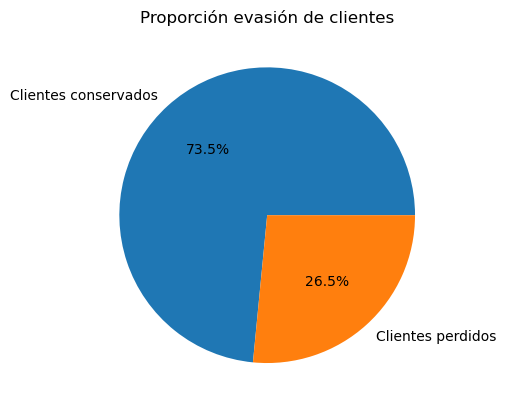

In [167]:
# Contar valores
churn_counts = df_transformed['CHURN'].value_counts()

# Definir etiquetas personalizadas
#labels = ['Clientes perdidos', 'Clientes conservados']
labels = ['Clientes conservados', 'Clientes perdidos']

# Graficar
plt.pie(churn_counts, labels=labels, autopct='%1.1f%%')
plt.title('Proporción evasión de clientes')
plt.show()

## Recuento de evasión por variables categóricas

In [169]:
def graficar_barras_agrupadas_2_cols(df_src, col_eje_x, col_eje_y):
    # Contamos el número total de clientes y los que tienen churn
    df_grouped = df_transformed.groupby([col_eje_x, col_eje_y]).size().unstack(fill_value=0)
    # Creación del gráfico
    fig, ax = plt.subplots()

    # Gráfico apilado
    df_grouped.plot(kind='bar', stacked=True, color=['blue', 'red'], ax=ax)

    # Añadir etiquetas y título
    ax.set_xlabel(col_eje_x)
    ax.set_ylabel(col_eje_y)
    ax.set_title(f'Clientes por {col_eje_x} y {col_eje_y}')
    ax.legend(title=col_eje_y, labels=df_src[col_eje_x].unique())

    # Añadir las cantidades en cada barra
    for index, row in df_grouped.iterrows():
        ax.text(index, row[0] / 2, str(row[0]), ha='center', color='white')
        ax.text(index, row[0] + row[1] / 2, str(row[1]), ha='center', color='white')

    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [170]:
# Columnas "inferidas" por los datos transformados
df_transformed['ES_INTERNET_FIBRA_OPTICA'] = (df_transformed['TIENE_SERV_INTERNET'] == True) & (df_transformed['TIENE_INTERNET_DSL'] == False)
df_transformed['TIENE_SERV_TEL'] = (df_transformed['TIENE_1_LIN_TEL'] == False) & (df_transformed['TIENE_MASDE_1_LIN_TEL'] == False)


C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:18: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:19: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



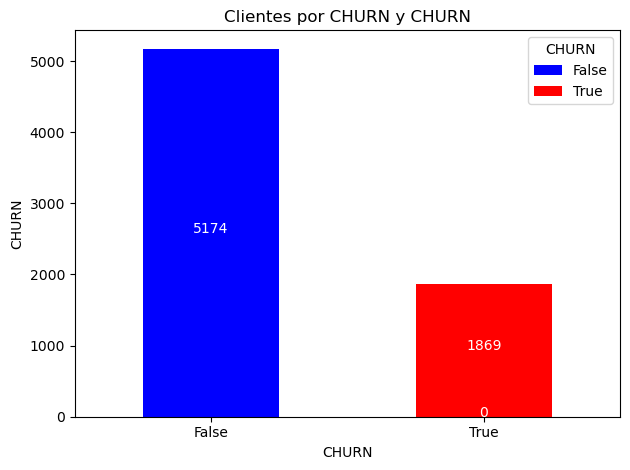

C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:18: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:19: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



Porcentaje de clientes que hicieron churn para cada valor de CHURN:            CHURN
False      0.0
True     100.0


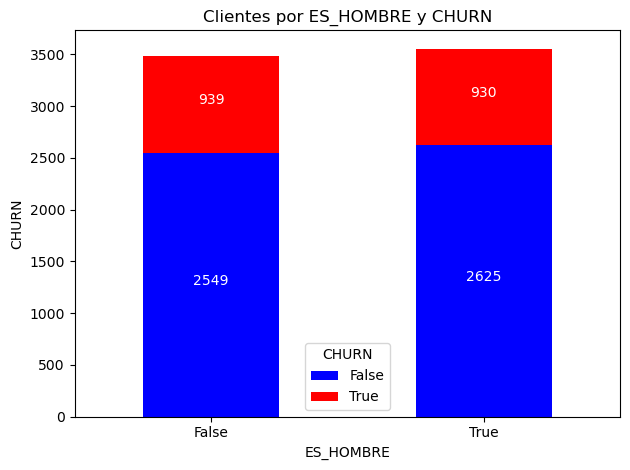

C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:18: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:19: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



Porcentaje de clientes que hicieron churn para cada valor de ES_HOMBRE:            ES_HOMBRE
False    26.920872
True     26.160338


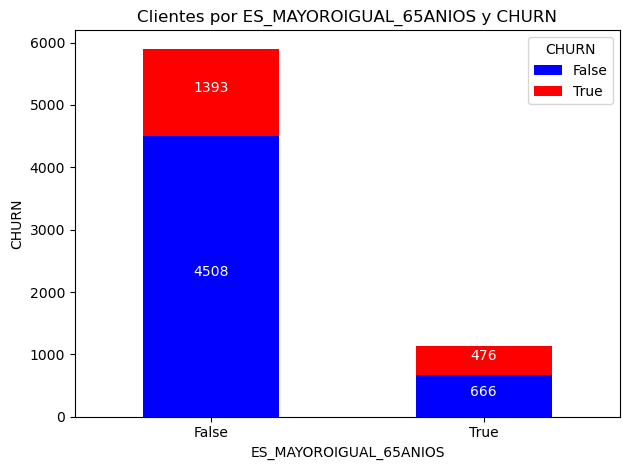

Porcentaje de clientes que hicieron churn para cada valor de ES_MAYOROIGUAL_65ANIOS:            ES_MAYOROIGUAL_65ANIOS
False    23.606168
True     41.681261


C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:18: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:19: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



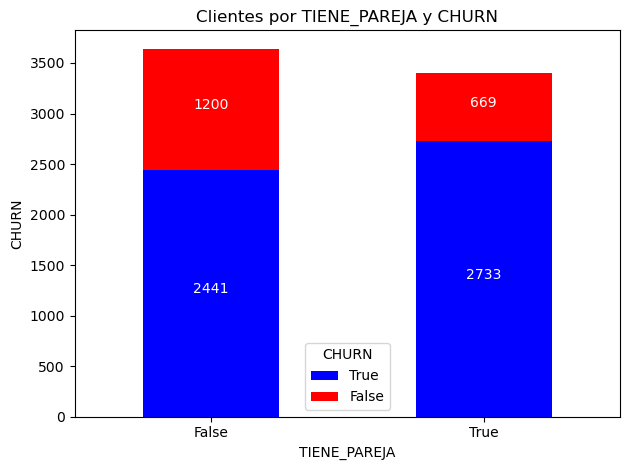

Porcentaje de clientes que hicieron churn para cada valor de TIENE_PAREJA:            TIENE_PAREJA
False    32.957979
True     19.664903


C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:18: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:19: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



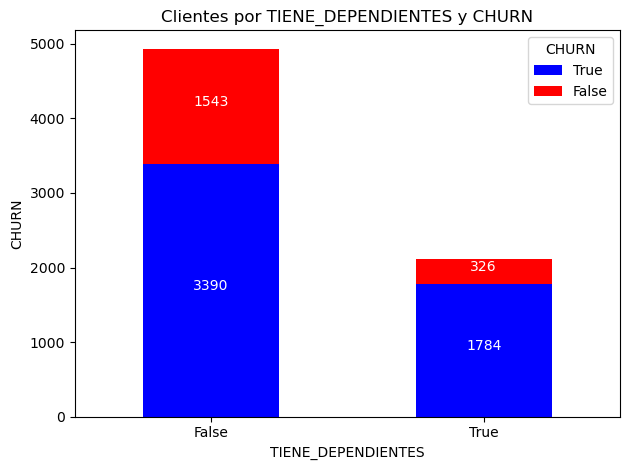

Porcentaje de clientes que hicieron churn para cada valor de TIENE_DEPENDIENTES:            TIENE_DEPENDIENTES
False    31.279140
True     15.450237


C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:18: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:19: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



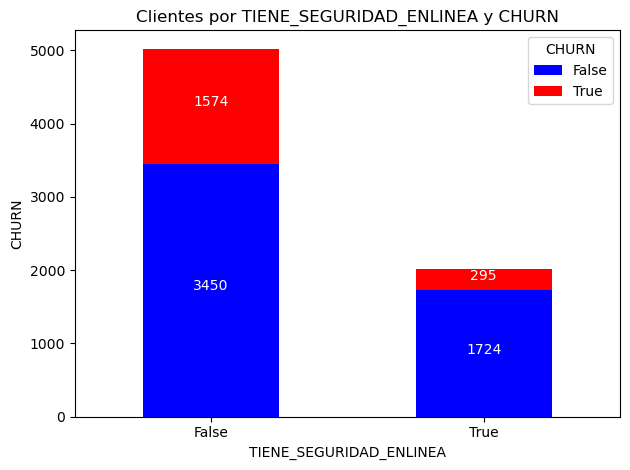

Porcentaje de clientes que hicieron churn para cada valor de TIENE_SEGURIDAD_ENLINEA:            TIENE_SEGURIDAD_ENLINEA
False    31.329618
True     14.611194


C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:18: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:19: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



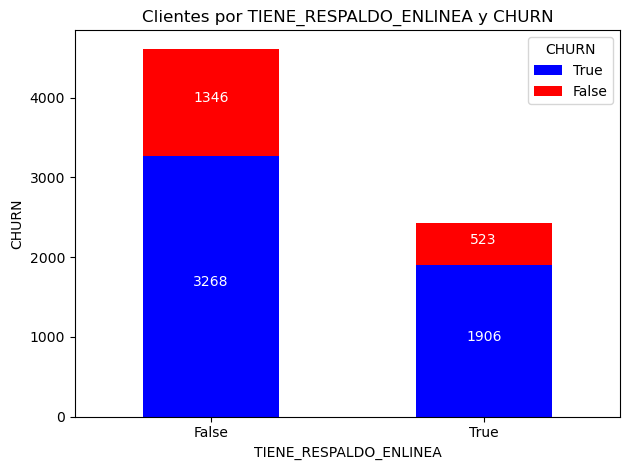

Porcentaje de clientes que hicieron churn para cada valor de TIENE_RESPALDO_ENLINEA:            TIENE_RESPALDO_ENLINEA
False    29.172085
True     21.531494


C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:18: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:19: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



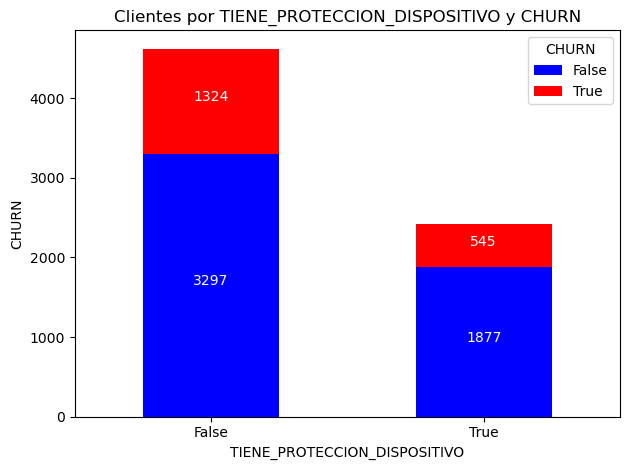

Porcentaje de clientes que hicieron churn para cada valor de TIENE_PROTECCION_DISPOSITIVO:            TIENE_PROTECCION_DISPOSITIVO
False    28.651807
True     22.502064


C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:18: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:19: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



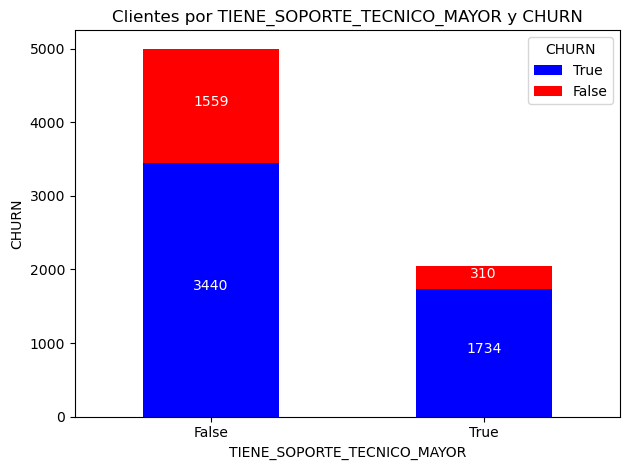

Porcentaje de clientes que hicieron churn para cada valor de TIENE_SOPORTE_TECNICO_MAYOR:            TIENE_SOPORTE_TECNICO_MAYOR
False    31.186237
True     15.166341


C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:18: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:19: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



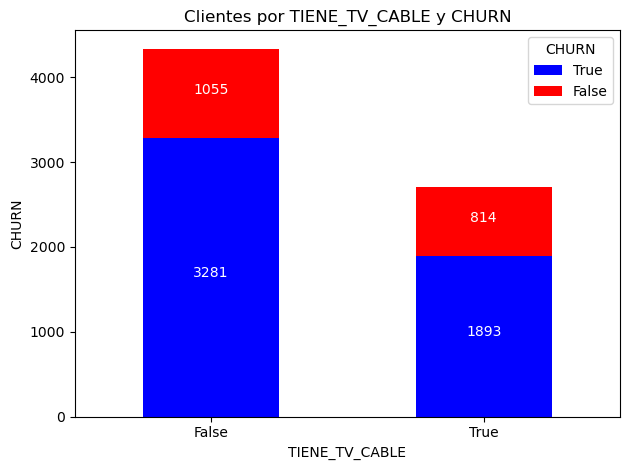

Porcentaje de clientes que hicieron churn para cada valor de TIENE_TV_CABLE:            TIENE_TV_CABLE
False    24.331181
True     30.070188


C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:18: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:19: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



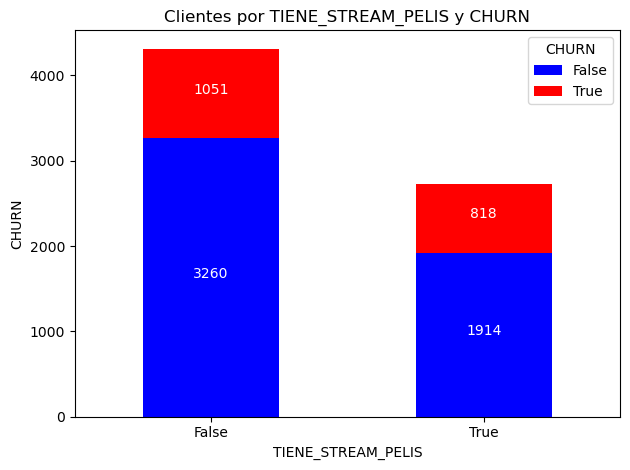

Porcentaje de clientes que hicieron churn para cada valor de TIENE_STREAM_PELIS:            TIENE_STREAM_PELIS
False    24.379494
True     29.941435


C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:18: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:19: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



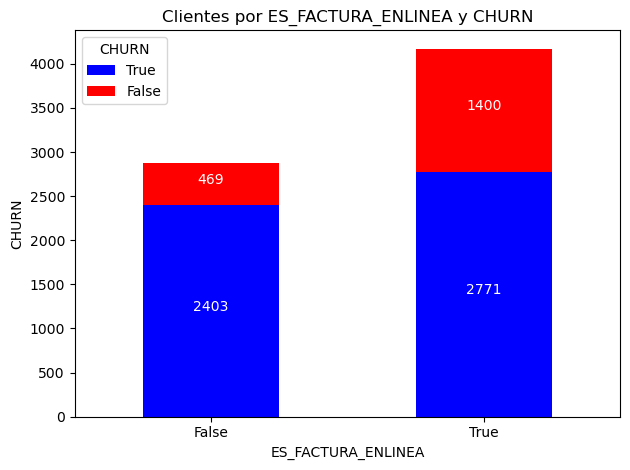

Porcentaje de clientes que hicieron churn para cada valor de ES_FACTURA_ENLINEA:            ES_FACTURA_ENLINEA
False    16.330084
True     33.565092


C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:18: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:19: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



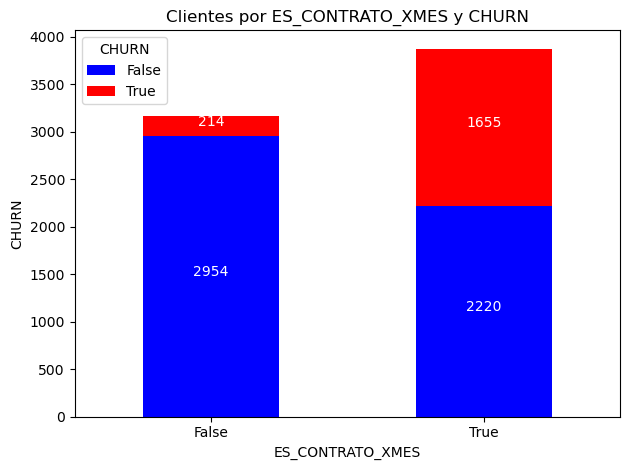

Porcentaje de clientes que hicieron churn para cada valor de ES_CONTRATO_XMES:            ES_CONTRATO_XMES
False     6.755051
True     42.709677


C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:18: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:19: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



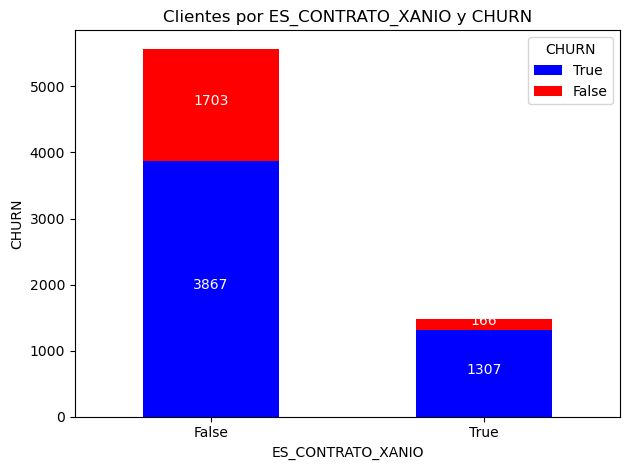

Porcentaje de clientes que hicieron churn para cada valor de ES_CONTRATO_XANIO:            ES_CONTRATO_XANIO
False    30.574506
True     11.269518


C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:18: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:19: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



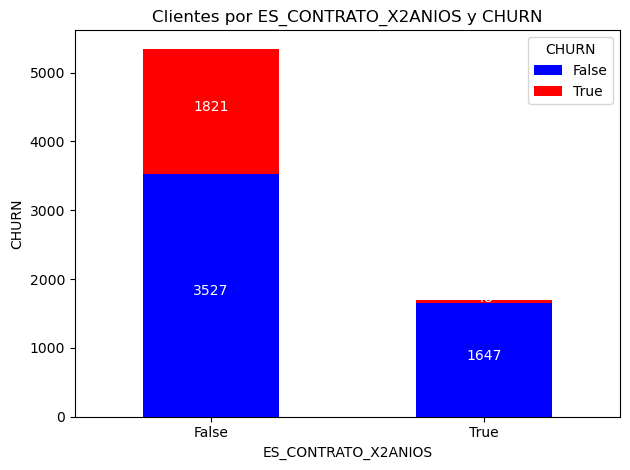

Porcentaje de clientes que hicieron churn para cada valor de ES_CONTRATO_X2ANIOS:            ES_CONTRATO_X2ANIOS
False    34.050112
True      2.831858


C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:18: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:19: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



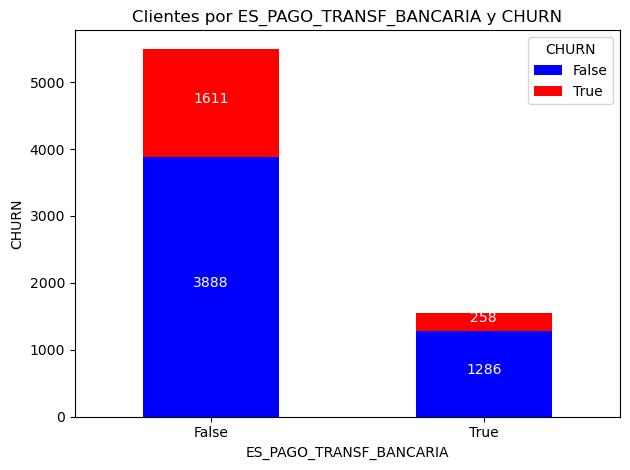

Porcentaje de clientes que hicieron churn para cada valor de ES_PAGO_TRANSF_BANCARIA:            ES_PAGO_TRANSF_BANCARIA
False    29.296236
True     16.709845


C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:18: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:19: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



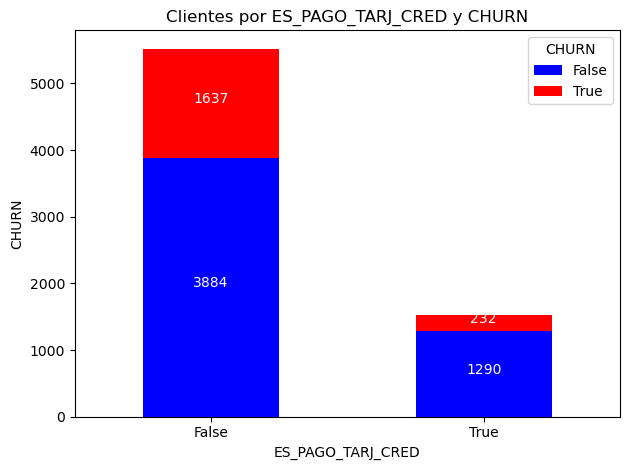

Porcentaje de clientes que hicieron churn para cada valor de ES_PAGO_TARJ_CRED:            ES_PAGO_TARJ_CRED
False    29.650426
True     15.243101


C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:18: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:19: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



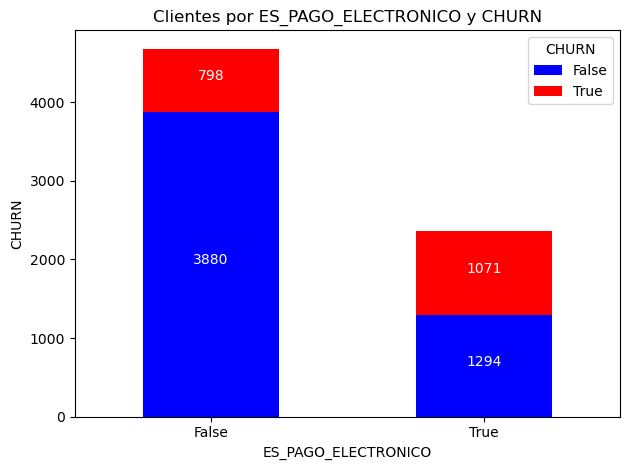

Porcentaje de clientes que hicieron churn para cada valor de ES_PAGO_ELECTRONICO:            ES_PAGO_ELECTRONICO
False    17.058572
True     45.285412


C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:18: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:19: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



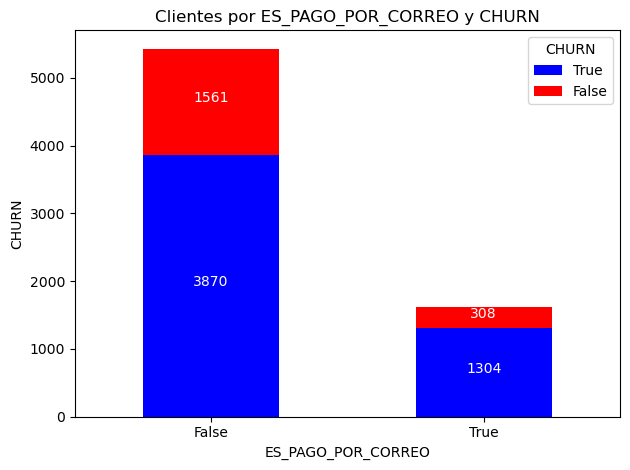

Porcentaje de clientes que hicieron churn para cada valor de ES_PAGO_POR_CORREO:            ES_PAGO_POR_CORREO
False    28.742405
True     19.106700


C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:18: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:19: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



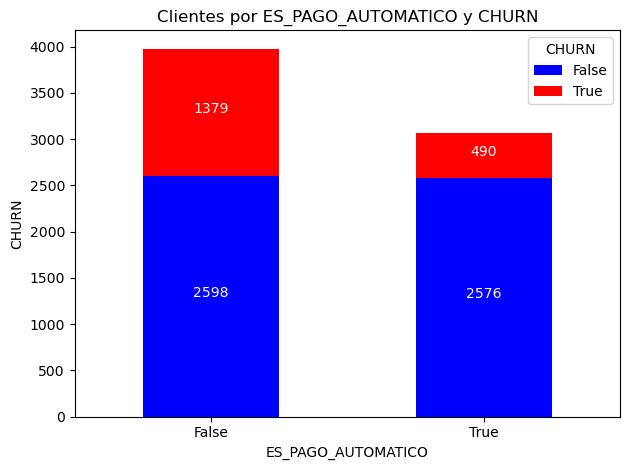

Porcentaje de clientes que hicieron churn para cada valor de ES_PAGO_AUTOMATICO:            ES_PAGO_AUTOMATICO
False    34.674378
True     15.981735


C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:18: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:19: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



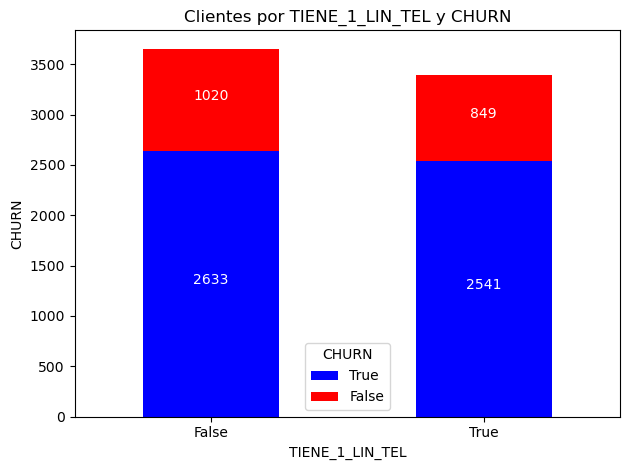

Porcentaje de clientes que hicieron churn para cada valor de TIENE_1_LIN_TEL:            TIENE_1_LIN_TEL
False    27.922256
True     25.044248


C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:18: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:19: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



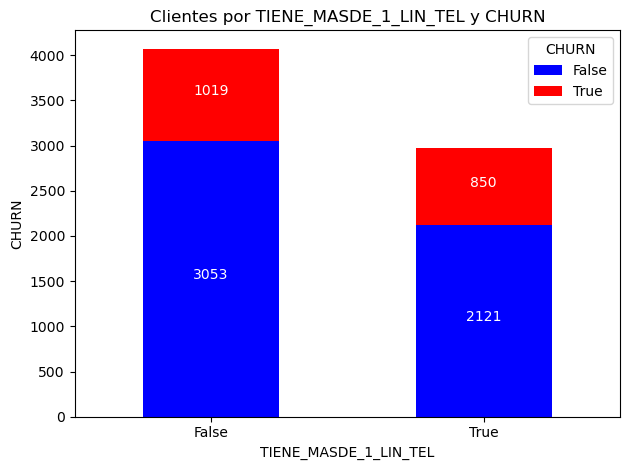

Porcentaje de clientes que hicieron churn para cada valor de TIENE_MASDE_1_LIN_TEL:            TIENE_MASDE_1_LIN_TEL
False    25.024558
True     28.609896


C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:18: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:19: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



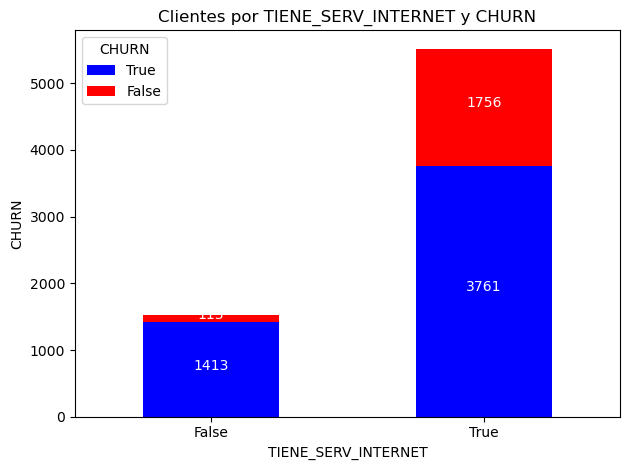

Porcentaje de clientes que hicieron churn para cada valor de TIENE_SERV_INTERNET:            TIENE_SERV_INTERNET
False     7.404980
True     31.828893


C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:18: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:19: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



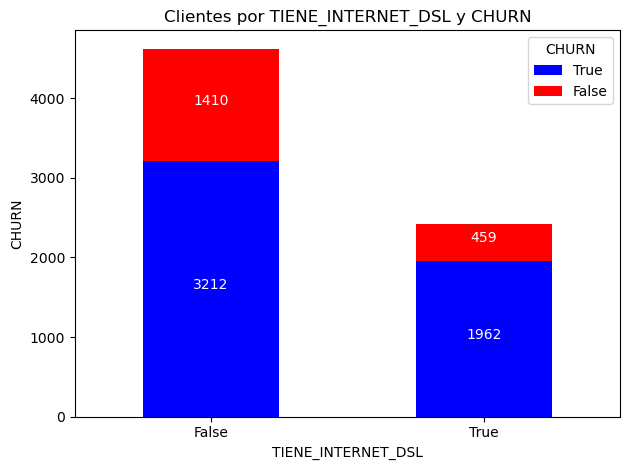

Porcentaje de clientes que hicieron churn para cada valor de TIENE_INTERNET_DSL:            TIENE_INTERNET_DSL
False    30.506274
True     18.959108


C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:18: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:19: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



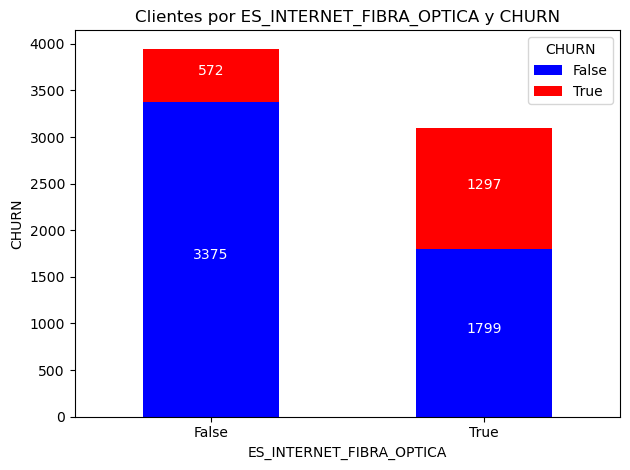

Porcentaje de clientes que hicieron churn para cada valor de ES_INTERNET_FIBRA_OPTICA:            ES_INTERNET_FIBRA_OPTICA
False    14.492019
True     41.892765


C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:18: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Nelly\AppData\Local\Temp\ipykernel_1928\1115432275.py:19: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



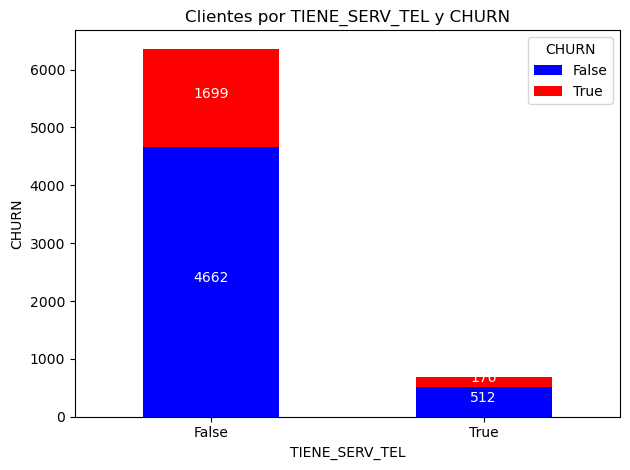

Porcentaje de clientes que hicieron churn para cada valor de TIENE_SERV_TEL:            TIENE_SERV_TEL
False    26.709637
True     24.926686


In [171]:
for col in df_transformed:
    if df_transformed[col].dtype == 'bool':
        graficar_barras_agrupadas_2_cols(df_transformed, col, 'CHURN')
        # Imprimir el porcentaje de clientes que hicieron churn para cada valor de la columna
        churn_percentages = df_transformed.groupby(col)['CHURN'].mean() * 100
        print(f'Porcentaje de clientes que hicieron churn para cada valor de {col}:\
            {churn_percentages.to_string()}')

In [172]:
'''
# Versión con plotly
import plotly.graph_objects as go

# Supongamos que ya tienes df_transformed como tu DataFrame
# df_transformed = pd.read_csv('ruta/a/tu/archivo.csv') # Cargar tu DataFrame

# Contamos el número total de clientes y los que tienen churn
df_grouped = df_transformed.groupby(['ES_HOMBRE', 'CHURN']).size().unstack(fill_value=0)

# Creación del gráfico con Plotly
fig = go.Figure()

# Añadir las trazas para cada tipo de CHURN
fig.add_trace(go.Bar(
    x=df_grouped.index,
    y=df_grouped[False],  # Clientes sin churn
    name='False',
    marker_color='blue',
    text=df_grouped[False],
    textposition='inside'
))

fig.add_trace(go.Bar(
    x=df_grouped.index,
    y=df_grouped[True],  # Clientes con churn
    name='True',
    marker_color='red',
    text=df_grouped[True],
    textposition='inside'
))

# Actualizar el diseño del gráfico
fig.update_layout(
    title='Clientes por género y churn',
    xaxis_title='ES_HOMBRE',
    yaxis_title='Número total de clientes',
    barmode='stack',
    legend_title='CHURN'
)

# Mostrar el gráfico
fig.show()
'''

"\n# Versión con plotly\nimport plotly.graph_objects as go\n\n# Supongamos que ya tienes df_transformed como tu DataFrame\n# df_transformed = pd.read_csv('ruta/a/tu/archivo.csv') # Cargar tu DataFrame\n\n# Contamos el número total de clientes y los que tienen churn\ndf_grouped = df_transformed.groupby(['ES_HOMBRE', 'CHURN']).size().unstack(fill_value=0)\n\n# Creación del gráfico con Plotly\nfig = go.Figure()\n\n# Añadir las trazas para cada tipo de CHURN\nfig.add_trace(go.Bar(\n    x=df_grouped.index,\n    y=df_grouped[False],  # Clientes sin churn\n    name='False',\n    marker_color='blue',\n    text=df_grouped[False],\n    textposition='inside'\n))\n\nfig.add_trace(go.Bar(\n    x=df_grouped.index,\n    y=df_grouped[True],  # Clientes con churn\n    name='True',\n    marker_color='red',\n    text=df_grouped[True],\n    textposition='inside'\n))\n\n# Actualizar el diseño del gráfico\nfig.update_layout(\n    title='Clientes por género y churn',\n    xaxis_title='ES_HOMBRE',\n    yaxis_

Convendría realizar estas comparaciones una vez balanceadas las clases de este tipo de columnas

## Conteo de evasión por variables numéricas

In [173]:
for col in df_transformed.columns:
    #if is_numeric_dtype(df_transformed[col]): # Considera que los bool son numéricos
    if is_numeric_dtype(df_transformed[col]) and df_transformed[col].dtype != 'bool':
        box_plot_fig = px.box(df_transformed, x='CHURN', y=col)
        box_plot_fig.show()

# 📄Informe final
